In [48]:
#loading the data

import pandas as pd

rfm = pd.read_csv("../data/rfm.csv", nrows=5)

print(rfm.shape)
rfm.head()

(5, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [49]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

In [50]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5.000000,5.00000,5.000000,5.000000
mean,12348.000000,146.40000,2.800000,17076.558000
std,1.581139,159.06068,2.683282,33631.350405
min,12346.000000,2.00000,1.000000,334.400000
25%,12347.000000,19.00000,1.000000,1757.550000
50%,12348.000000,75.00000,1.000000,1797.240000
75%,12349.000000,310.00000,4.000000,4310.000000
max,12350.000000,326.00000,7.000000,77183.600000


In [51]:
import numpy as np

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [52]:
#Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [53]:
#checking the shape of the scaling parameter

rfm_scaled.shape

(5, 4)

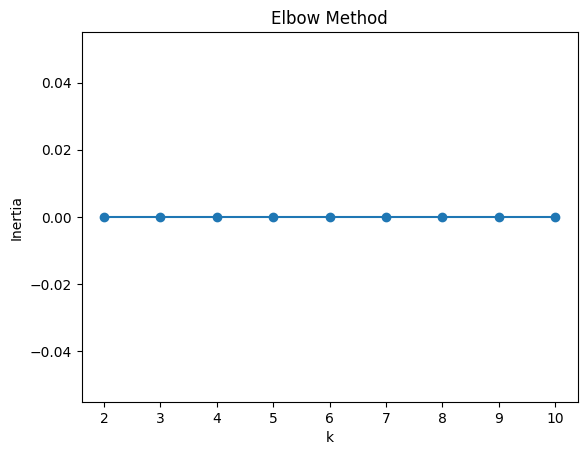

In [54]:
# Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [55]:
# Train Model

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(rfm_scaled)

In [56]:
print("Shape:", rfm_scaled.shape)
print("Labels:", set(labels))

Shape: (5, 4)
Labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}


In [57]:
score = silhouette_score(rfm_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.03237591778855296


In [60]:
rfm['Cluster'] = labels

In [ ]:
# Understanding the Clusters

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print(cluster_summary)

         Recency  Frequency  Monetary
Cluster                              
0            2.0        7.0    4310.0
1           47.0        2.5    1777.4
2          326.0        1.0   77183.6
3          310.0        1.0     334.4


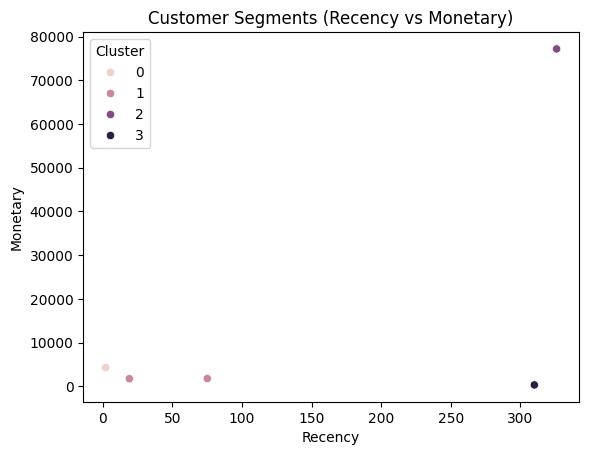

In [63]:
# Cluster Scatter Plot

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster'
)

plt.title("Customer Segments (Recency vs Monetary)")
plt.show()

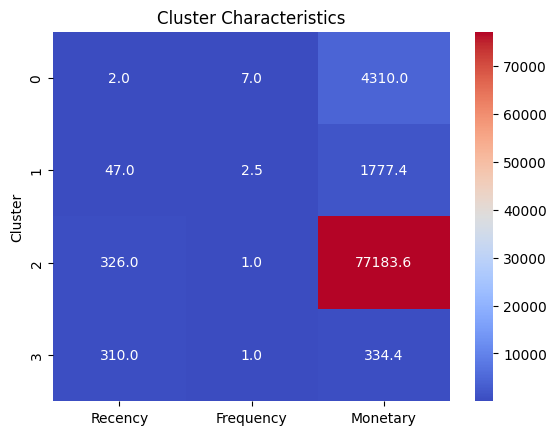

In [64]:
# Heatmap of Cluster Means

import seaborn as sns

sns.heatmap(cluster_summary, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Cluster Characteristics")
plt.show()

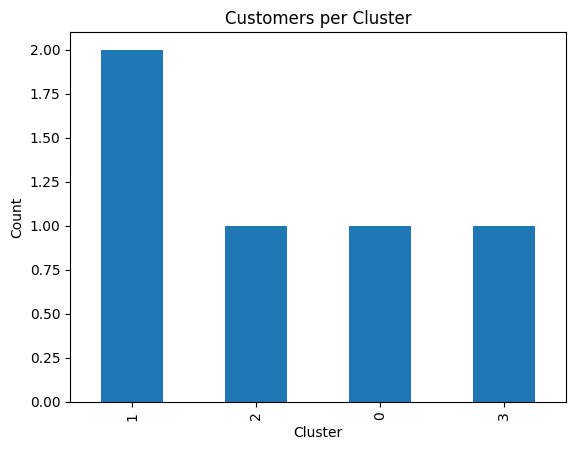

In [65]:
# Cluster Size Distribution

rfm['Cluster'].value_counts().plot(kind='bar')
plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [73]:
import os

os.makedirs("data/processed", exist_ok=True)
rfm.to_csv("data/processed/rfm_segmented.csv")